# Sample statistics

In [1]:
from wilds import *
from datetime import datetime
import pandas as pd
import pytz
import numpy as np

In [2]:
dataset = get_dataset(dataset="fmow", download=False, root_dir="/home/erik/git/bigpicture/data")
metadata = dataset.metadata
split_names = ['train', 'val', 'test', 'id_val', 'id_test']
subsets_indices = [dataset.get_subset(split_name).indices for split_name in split_names]
fmow_wilds_indices = np.concatenate(subsets_indices)
print(len(fmow_wilds_indices))

141696


In [3]:
metadata['timestamp_dt'] = pd.to_datetime(metadata['timestamp'])

utc = pytz.UTC
id_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2002, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2012 + 1, 1, 1)))
ood_val_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2013, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2015 + 1, 1, 1)))
ood_test_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2016, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2017 + 1, 1, 1)))
train_mask = (metadata['split'] == 'train')
val_mask = (metadata['split'] == 'val')
test_mask = (metadata['split'] == 'test')
train_len = len(metadata[id_mask & train_mask])
val_len = len(metadata[ood_val_mask & val_mask])
test_len = len(metadata[ood_test_mask & test_mask])
id_val_len = len(metadata[id_mask & val_mask])
id_test_len = len(metadata[id_mask & test_mask])
print(train_len, val_len, test_len, id_val_len, id_test_len)
print(train_len + val_len + test_len + id_val_len + id_test_len)

76863 19915 22108 11483 11327
141696


# Compute the time span of the fMoW WILDS dataset

In [4]:
import pandas as pd
df = pd.read_csv(
    "~/git/bigpicture/data/fmow_v1.1/rgb_metadata.csv",
    parse_dates=["timestamp"],
    date_format="%Y-%m-%dT%H:%M:%SZ"
) 

print(
    df["timestamp"].min(), 
    df["timestamp"].max() 
)

2002-01-28 07:04:18 2017-07-12 08:25:25


# Show image spans of FMoW WILDS dataset and compute resolution

In [5]:
import pandas as pd
df = pd.read_csv(
    "/home/erik/git/bigpicture/data/fmow_landsat/rgb_metadata_extended.csv"
    )

In [6]:
min_span = df["img_span_km"].min()
max_span = df["img_span_km"].max()
max_res = min_span * 1000 / 224
min_res = max_span * 1000 / 224

print(f"Max resolution = {max_res:.2f} m/px with {max_span} km span. The HR would be represented by {max_res * 224 / 30:.2f} px at 30 m/px resolution.")
print(f"Min resolution = {min_res:.2f} m/px with {min_span} km span. The HR would be represented by {min_res * 224 / 30:.2f} px at 30 m/px resolution.")

print(f"Relation between the scales ranges between {30 / max_res:.2f} and {30 / min_res:.2f}.")

Max resolution = 0.61 m/px with 4.982763570862209 km span. The HR would be represented by 4.54 px at 30 m/px resolution.
Min resolution = 22.24 m/px with 0.1363199163954886 km span. The HR would be represented by 166.09 px at 30 m/px resolution.
Relation between the scales ranges between 49.30 and 1.35.


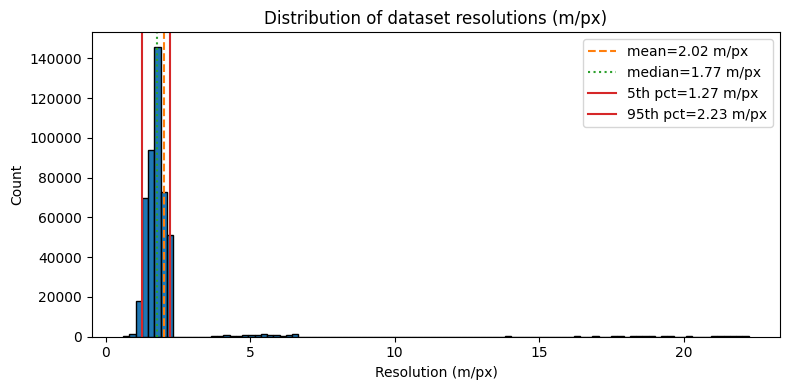

In [14]:
import matplotlib.pyplot as plt

res_mpx = df["img_span_km"].dropna() * 1000 / 224
# 95% of images have a higher resolution (smaller m/px) than this value.
p95 = res_mpx.quantile(0.95)
p5 = res_mpx.quantile(0.05)

plt.figure(figsize=(8,4))
plt.hist(res_mpx, bins=100, color='C0', edgecolor='k')
plt.axvline(res_mpx.mean(), color='C1', linestyle='--', label=f"mean={res_mpx.mean():.2f} m/px")
plt.axvline(res_mpx.median(), color='C2', linestyle=':', label=f"median={res_mpx.median():.2f} m/px")
plt.axvline(p5, color='C3', linestyle='-', label=f"5th pct={p5:.2f} m/px")
plt.axvline(p95, color='C3', linestyle='-', label=f"95th pct={p95:.2f} m/px")
plt.xlabel("Resolution (m/px)")
plt.ylabel("Count")
plt.title("Distribution of dataset resolutions (m/px)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
lr_image_size = 4.982763570862209 * 3 / 30 * 1000
lr_res = lr_image_size / 224 * 30
print(f"LR image size = {lr_image_size:.2f} px. LR has a resolution of {lr_res:.2f} m/px.")

LR image size = 498.28 px. LR has a resolution of 66.73 m/px.


In [9]:
# Count samples per region per dataset split using timestamp-based masks
# Ensure timestamp column converted
if 'timestamp_dt' not in metadata.columns:
    metadata['timestamp_dt'] = pd.to_datetime(metadata['timestamp'])

# Define time-based masks
utc = pytz.UTC
id_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2002, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2012 + 1, 1, 1)))
ood_val_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2013, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2015 + 1, 1, 1)))
ood_test_mask = (metadata['timestamp_dt'] >= utc.localize(datetime(2016, 1, 1))) & (metadata['timestamp_dt'] < utc.localize(datetime(2017 + 1, 1, 1)))

# Define split masks
train_mask = (metadata['split'] == 'train')
val_mask = (metadata['split'] == 'val')
test_mask = (metadata['split'] == 'test')

# Map split names to the combined masks used in the earlier logic
split_masks = {
    'train': id_mask & train_mask,
    'val': ood_val_mask & val_mask,
    'test': ood_test_mask & test_mask,
    'id_val': id_mask & val_mask,
    'id_test': id_mask & test_mask,
}

parts = []
for name, mask in split_masks.items():
    s = metadata.loc[mask].groupby('region').size()
    s.name = name
    parts.append(s)
counts = pd.concat(parts, axis=1).fillna(0).astype(int)
# Ensure consistent ordering
counts = counts.reindex(columns=['train', 'val', 'test', 'id_val', 'id_test'], fill_value=0)
print('Samples per region (rows) × split (columns):')
print(counts)
print('\nTotals per split:')
print(counts.sum(axis=0))
print('\nTotals per region:')
print(counts.sum(axis=1))
print('\nTotals per region in-domain:')
print(counts[['train', 'id_val', 'id_test']].sum(axis=1))
print('\nTotals per region out-of-domain:')
print(counts[['val', 'test']].sum(axis=1))
# Sanity: print totals previously computed in notebook if present
try:
    train_len = len(metadata[id_mask & train_mask])
    val_len = len(metadata[ood_val_mask & val_mask])
    test_len = len(metadata[ood_test_mask & test_mask])
    id_val_len = len(metadata[id_mask & val_mask])
    id_test_len = len(metadata[id_mask & test_mask])
    print('\nSanity counts (train, val, test, id_val, id_test):')
    print(train_len, val_len, test_len, id_val_len, id_test_len)
    print('Sum total:', train_len + val_len + test_len + id_val_len + id_test_len)
except Exception:
    pass


Samples per region (rows) × split (columns):
        train   val  test  id_val  id_test
region                                    
0       17809  4121  4963    2693     2615
1       34816  7732  5858    5268     5150
2        1582   803  2593     190      209
3       20973  6562  8024    3076     3130
4        1641   693   666     251      218
5          42     4     4       5        5

Totals per split:
train      76863
val        19915
test       22108
id_val     11483
id_test    11327
dtype: int64

Totals per region:
region
0    32201
1    58824
2     5377
3    41765
4     3469
5       60
dtype: int64

Totals per region in-domain:
region
0    23117
1    45234
2     1981
3    27179
4     2110
5       52
dtype: int64

Totals per region out-of-domain:
region
0     9084
1    13590
2     3396
3    14586
4     1359
5        8
dtype: int64

Sanity counts (train, val, test, id_val, id_test):
76863 19915 22108 11483 11327
Sum total: 141696


# Spatial extent ablation

In [10]:
# Spatial extend ablation:
resolutions = [p95 * 2.0, p95 * 3.0, 15, 30, 45, max_span * 3.0 * 1000 / 224]
print(resolutions)

extends = [p95 * 224 * 2.0, p95 * 224 * 3.0, 15 * 224, 30 * 224, 45 * 224, max_span * 3.0]
print(extends)

[np.float64(4.4681380514206985), np.float64(6.702207077131048), 15, 30, 45, np.float64(66.7334406811903)]
[np.float64(1000.8629235182365), np.float64(1501.2943852773546), 3360, 6720, 10080, np.float64(14.948290712586628)]
